# LangGraph Single Agent — 4 Real Tools

A single ReAct-style LangGraph agent wired to **4 real tools**:

1. `create_file` — writes a file to disk
2. `read_file` — reads a file back from disk
3. `list_files` — lists files in the working directory (utility tool)
4. `get_weather` — live weather lookup via the free **Open-Meteo** API (no API key required)

**LLM provider toggle** — set `PROVIDER` below to either:

- `"openai"` — uses `langchain_openai.ChatOpenAI` with your `OPENAI_API_KEY`
- `"bcai"` — uses Boeing's internal **BCAI** chat model (`BoeingChatModel`, bundled as `boeing_chat_model.py` next to this notebook). Requires a `BCAI_UDAL_PAT` token and (if you're on Boeing VPN/network) access to `bcai-test.web.boeing.com`.

Run this in VS Code with the Jupyter extension (select a Python kernel with the packages below installed).


## 1. Install dependencies

Run once. Uncomment if packages aren't already installed in your kernel.

In [1]:
%pip install -U langgraph langchain langchain-openai langchain-core requests python-dotenv


  Using cached langchain_core-1.6.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached langgraph_prebuilt-1.1.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached langsmith-0.11.1-py3-none-any.whl.metadata (22 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached jsonpointer-3.1.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached ormsgpack-1.12.2-cp313-cp313-macosx_10_12_x86_64.macosx_11_0_arm64.macosx_10_12_universal2.whl.metadata (3.2 kB)
  Using cached websockets-16.1.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached httpx2-2.12.0-py3-none-any.whl.metadata (9.5 kB)
  Using cached jiter-0.16.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached httpcore2-

## 2. Configuration — pick your provider

Set `PROVIDER = "openai"` or `PROVIDER = "bcai"`.

Credentials are read from environment variables (use a `.env` file or `os.environ[...] = "..."`
directly — never hardcode secrets in the notebook):

| Provider | Env var(s) | Notes |
|---|---|---|
| `openai` | `OPENAI_API_KEY` | standard OpenAI key |
| `bcai` | `BCAI_UDAL_PAT` | Boeing internal UDAL PAT token; optionally `BCAI_API_URL`, `BCAI_MODEL` to override defaults |


In [2]:
import os

# Load .env if present (optional convenience — safe no-op if python-dotenv isn't installed)
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

# ---- Choose your provider here ----
PROVIDER = os.environ.get("AGENT_PROVIDER", "openai")  # "openai" or "bcai"

print(f"Using provider: {PROVIDER}")


Using provider: openai


In [ ]:
def build_llm(provider: str = PROVIDER):
    '''Factory that returns a LangChain-compatible chat model for the chosen provider.'''
    if provider == "openai":
        from langchain_openai import ChatOpenAI

        api_key = "sk-proj--Oj9U_g7N68r0EI-"
        if not api_key:
            raise RuntimeError("OPENAI_API_KEY is not set. Set it in your environment or .env file.")

        return ChatOpenAI(
            model=os.environ.get("OPENAI_MODEL", "gpt-4o-mini"),
            temperature=0,
            api_key=api_key,
        )

    elif provider == "bcai":
        # BoeingChatModel is Boeing's internal LangChain-compatible wrapper around the
        # proprietary BCAI API. Bundled as boeing_chat_model.py alongside this notebook.
        from boeing_chat_model import BoeingChatModel

        udal_pat = os.environ.get("BCAI_UDAL_PAT")
        if not udal_pat:
            raise RuntimeError("BCAI_UDAL_PAT is not set. Set it in your environment or .env file.")

        kwargs = {"udal_pat": udal_pat}
        if os.environ.get("BCAI_API_URL"):
            kwargs["api_url"] = os.environ["BCAI_API_URL"]
        if os.environ.get("BCAI_MODEL"):
            kwargs["model"] = os.environ["BCAI_MODEL"]

        return BoeingChatModel(**kwargs, temperature=0)

    else:
        raise ValueError(f"Unknown provider: {provider!r}. Use 'openai' or 'bcai'.")


llm = build_llm()
llm


ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.17', 'langchain-openai': '1.6.0'}}, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x113ba1400>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x113ba1e80>, root_client=<openai.OpenAI object at 0x112bbf770>, root_async_client=

## 3. Define the 4 tools

Real, working implementations:

- File tools operate inside a sandboxed `./agent_workspace` directory (so the agent can't write
  arbitrary paths on your machine).
- `get_weather` calls the free [Open-Meteo](https://open-meteo.com/) geocoding + forecast APIs —
  no API key needed.


In [5]:
import json
from pathlib import Path
from typing import Optional

import requests
from langchain_core.tools import tool

# Sandbox directory for file tools — keeps the agent from writing anywhere on disk.
WORKSPACE_DIR = Path("./agent_workspace").resolve()
WORKSPACE_DIR.mkdir(exist_ok=True)


def _safe_path(filename: str) -> Path:
    '''Resolve filename inside WORKSPACE_DIR and block path traversal.'''
    candidate = (WORKSPACE_DIR / filename).resolve()
    if WORKSPACE_DIR not in candidate.parents and candidate != WORKSPACE_DIR:
        raise ValueError(f"Refusing to access path outside workspace: {filename}")
    return candidate


@tool
def create_file(filename: str, content: str) -> str:
    '''Create (or overwrite) a text file in the agent workspace with the given content.

    Args:
        filename: Name of the file to create, e.g. "notes.txt".
        content: Text content to write into the file.
    '''
    path = _safe_path(filename)
    path.write_text(content, encoding="utf-8")
    return f"Created file '{filename}' ({len(content)} chars) at {path}"


@tool
def read_file(filename: str) -> str:
    '''Read and return the text content of a file in the agent workspace.

    Args:
        filename: Name of the file to read, e.g. "notes.txt".
    '''
    path = _safe_path(filename)
    if not path.exists():
        return f"Error: file '{filename}' does not exist in the workspace."
    return path.read_text(encoding="utf-8")


@tool
def list_files() -> str:
    '''List all files currently in the agent workspace.'''
    files = sorted(p.name for p in WORKSPACE_DIR.iterdir() if p.is_file())
    if not files:
        return "The workspace is empty."
    return "Files in workspace:\n" + "\n".join(f"- {f}" for f in files)


@tool
def get_weather(city: str) -> str:
    '''Get the current weather for a city using the free Open-Meteo API (no API key required).

    Args:
        city: City name, e.g. "Boston" or "Bengaluru".
    '''
    # Step 1: geocode the city name to lat/lon
    geo_resp = requests.get(
        "https://geocoding-api.open-meteo.com/v1/search",
        params={"name": city, "count": 1},
        timeout=10,
    )
    geo_resp.raise_for_status()
    geo_data = geo_resp.json()

    results = geo_data.get("results")
    if not results:
        return f"Could not find location data for '{city}'."

    place = results[0]
    lat, lon = place["latitude"], place["longitude"]
    resolved_name = f"{place.get('name')}, {place.get('country', '')}".strip(", ")

    # Step 2: fetch current weather for the coordinates
    weather_resp = requests.get(
        "https://api.open-meteo.com/v1/forecast",
        params={
            "latitude": lat,
            "longitude": lon,
            "current_weather": True,
            "timezone": "auto",
        },
        timeout=10,
    )
    weather_resp.raise_for_status()
    current = weather_resp.json().get("current_weather", {})

    if not current:
        return f"Weather data unavailable for {resolved_name}."

    return (
        f"Current weather in {resolved_name}: "
        f"{current.get('temperature')}°C, "
        f"wind {current.get('windspeed')} km/h, "
        f"as of {current.get('time')} (local time)."
    )


TOOLS = [create_file, read_file, list_files, get_weather]
[t.name for t in TOOLS]


['create_file', 'read_file', 'list_files', 'get_weather']

## 4. Build the LangGraph ReAct agent

`langgraph.prebuilt.create_react_agent` wires the LLM + tools into a working agent graph
(reason → call tool → observe → repeat → final answer) in one call.


/var/folders/lj/k63t253s7mq033nmfxqprknm0000gn/T/ipykernel_11760/3214448216.py:13: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, TOOLS, prompt=SYSTEM_PROMPT)


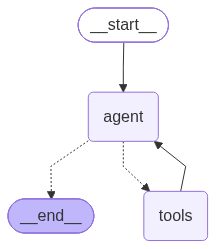

In [6]:
# Note: on very recent langgraph/langchain versions this raises a deprecation
# warning pointing to langchain.agents.create_agent — it still works fine.
from langgraph.prebuilt import create_react_agent

SYSTEM_PROMPT = (
    "You are a helpful assistant with access to file tools and a live weather tool. "
    "Use create_file/read_file/list_files to manage files in the workspace, and "
    "get_weather to answer questions about current weather. "
    "Always use a tool when the user's request requires it — do not guess file "
    "contents or weather data."
)

agent = create_react_agent(llm, TOOLS, prompt=SYSTEM_PROMPT)
agent


## 5. Run it — real scenario

Ask the agent to check live weather, then save the result to a file, then read it back.

In [7]:
def run_agent(user_message: str):
    result = agent.invoke({"messages": [("user", user_message)]})
    final_message = result["messages"][-1]
    print(final_message.content)
    return result


result = run_agent(
    "Check the current weather in Bengaluru, then save a short summary of it "
    "to a file called weather_report.txt, then confirm by reading the file back."
)


The current weather in Bengaluru is 28.8°C with a wind speed of 17.6 km/h. This summary has been saved to the file **weather_report.txt**. Here is the content of the file:

**Current weather in Bengaluru, India: 28.8°C, wind 17.6 km/h.**


### Inspect the full message trace (tool calls + observations)

In [8]:
for m in result["messages"]:
    role = m.__class__.__name__
    content = m.content if isinstance(m.content, str) else json.dumps(m.content)
    tool_calls = getattr(m, "tool_calls", None)
    print(f"[{role}] {content[:300]}")
    if tool_calls:
        for tc in tool_calls:
            print(f"    -> tool_call: {tc['name']}({tc['args']})")
    print("-" * 60)


[HumanMessage] Check the current weather in Bengaluru, then save a short summary of it to a file called weather_report.txt, then confirm by reading the file back.
------------------------------------------------------------
[AIMessage] 
    -> tool_call: get_weather({'city': 'Bengaluru'})
------------------------------------------------------------
[ToolMessage] Current weather in Bengaluru, India: 28.8°C, wind 17.6 km/h, as of 2026-08-27T14:00 (local time).
------------------------------------------------------------
[AIMessage] 
    -> tool_call: create_file({'filename': 'weather_report.txt', 'content': 'Current weather in Bengaluru, India: 28.8°C, wind 17.6 km/h.'})
------------------------------------------------------------
[ToolMessage] Created file 'weather_report.txt' (60 chars) at /Users/shukranaahmed/Downloads/agent_workspace/weather_report.txt
------------------------------------------------------------
[AIMessage] 
    -> tool_call: read_file({'filename': 'weather_report.tx

In [9]:
# Sanity check: list what actually landed on disk
print(list_files.invoke({}))


Files in workspace:
- weather_report.txt


## 6. Try more scenarios

Uncomment and run any of these:


In [11]:
run_agent("What's the weather like in Tokyo right now?")
run_agent("List every file currently in the workspace.")
run_agent("Read back weather_report.txt and summarize it in one sentence.")


The current weather in Tokyo is 25.0°C with a wind speed of 2.7 km/h.
The current file in the workspace is:

- weather_report.txt
The current weather in Bengaluru, India is 28.8°C with a wind speed of 17.6 km/h.


{'messages': [HumanMessage(content='Read back weather_report.txt and summarize it in one sentence.', additional_kwargs={}, response_metadata={}, id='15695abc-e9d8-425b-97a8-6e24ae1ba96a'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 278, 'total_tokens': 294, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5691373d70', 'id': 'chatcmpl-EHPxaQ9kM363O5BUDZOErE3L2jq0L', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a04261-64a8-7741-88ac-5c26f8644da3-0', tool_calls=[{'name': 'read_file', 'args': {'filename': 'weather_